# Notebook 4: Evaluation & Baseline Comparison
**Purpose:** Load the trained BERT model from NB2, evaluate it on the test set,  
compare against classical baselines, and generate the final results summary.  
**Link:** Uses `train/val/test.csv` from NB1 and `bert_sentiment/` model from NB2

---

## 4.1 Imports & Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from tqdm import tqdm

# Load preprocessed splits (output of Notebook 1)
train_df = pd.read_csv('../data/train.csv')
val_df   = pd.read_csv('../data/val.csv')
test_df  = pd.read_csv('../data/test.csv')
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Train: 35,000 | Val: 7,500 | Test: 7,500
Device: cpu


## 4.2 Load Saved BERT Model from Notebook 2

We load the best checkpoint saved by Notebook 2 and run a full evaluation  
on the held-out test set. No hardcoded numbers — all metrics are computed live.

In [8]:
# Load the model and tokenizer saved by Notebook 2
MODEL_PATH = '../models/bert_sentiment'
bert_model     = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
bert_tokenizer = DistilBertTokenizer.from_pretrained(MODEL_PATH)
bert_model.eval()
print(f'✅ BERT model loaded from {MODEL_PATH}')

✅ BERT model loaded from ../models/bert_sentiment


## 4.3 Build Test DataLoader for BERT

In [9]:
MAX_LEN    = 128
BATCH_SIZE = 32

class IMDbDataset(Dataset):
    """Same dataset class as used in Notebook 2."""
    def __init__(self, reviews, labels, tokenizer, max_len):
        self.reviews   = reviews.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        encoding = self.tokenizer.encode_plus(
            str(self.reviews[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_dataset = IMDbDataset(test_df['cleaned_review'], test_df['label'],
                           bert_tokenizer, MAX_LEN)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f'✅ Test DataLoader ready — {len(test_dataset):,} samples, {len(test_loader)} batches')

✅ Test DataLoader ready — 7,500 samples, 235 batches


## 4.4 Evaluate BERT on Test Set

In [10]:
def eval_bert(model, loader, device):
    """Run full evaluation — returns loss, accuracy, predictions, and true labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating BERT'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs        = model(input_ids, attention_mask=attention_mask)
            preds          = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

bert_preds, bert_true = eval_bert(bert_model, test_loader, device)

bert_acc = accuracy_score(bert_true, bert_preds)
bert_f1  = f1_score(bert_true, bert_preds)

print('=== BERT Test Set Performance ===')
print(f'Accuracy : {bert_acc:.4f}')
print(f'F1 Score : {bert_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(bert_true, bert_preds, target_names=['Negative', 'Positive']))

Evaluating BERT: 100%|██████████| 235/235 [12:05<00:00,  3.09s/it]

=== BERT Test Set Performance ===
Accuracy : 0.8983
F1 Score : 0.8972

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.91      0.90      3750
    Positive       0.91      0.89      0.90      3750

    accuracy                           0.90      7500
   macro avg       0.90      0.90      0.90      7500
weighted avg       0.90      0.90      0.90      7500



## 4.5 Baseline Models (TF-IDF + Classical ML)

In [11]:
X_train = train_df['cleaned_review']
y_train = train_df['label']
X_test  = test_df['cleaned_review']
y_test  = test_df['label']

baselines = {
    'Logistic Regression': Pipeline([('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
                                     ('clf',   LogisticRegression(max_iter=1000, C=1.0))]),
    'Naive Bayes':         Pipeline([('tfidf', TfidfVectorizer(max_features=20000)),
                                     ('clf',   MultinomialNB(alpha=0.1))]),
    'Linear SVM':          Pipeline([('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
                                     ('clf',   LinearSVC(C=1.0, max_iter=2000))]),
}

results = {}
for name, pipeline in baselines.items():
    print(f'Training {name}...')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    results[name] = {'Accuracy': acc, 'F1 Score': f1}
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f}')

# Add BERT — live values computed in section 4.4 above
results['BERT (Fine-tuned)'] = {'Accuracy': bert_acc, 'F1 Score': bert_f1}

results_df = pd.DataFrame(results).T
print('\n=== Model Comparison Table ===')
print(results_df.round(4).to_string())

Training Logistic Regression...
  Accuracy: 0.9051 | F1: 0.9059
Training Naive Bayes...
  Accuracy: 0.8607 | F1: 0.8609
Training Linear SVM...
  Accuracy: 0.9056 | F1: 0.9061

=== Model Comparison Table ===
                     Accuracy  F1 Score
Logistic Regression    0.9051    0.9059
Naive Bayes            0.8607    0.8609
Linear SVM             0.9056    0.9061
BERT (Fine-tuned)      0.8983    0.8972


## 4.6 Model Comparison Chart

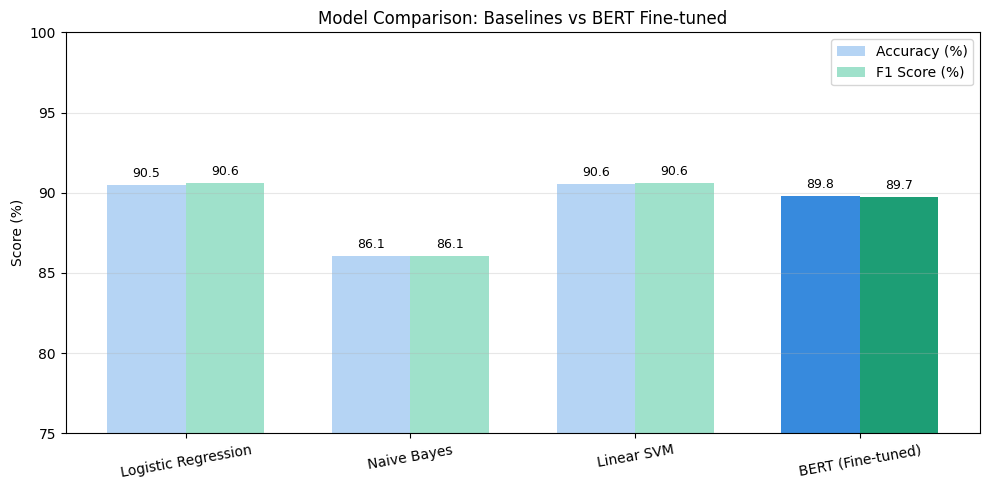

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'] * 100, width, label='Accuracy (%)',
               color=['#B5D4F4', '#B5D4F4', '#B5D4F4', '#378ADD'])
bars2 = ax.bar(x + width/2, results_df['F1 Score'] * 100, width, label='F1 Score (%)',
               color=['#9FE1CB', '#9FE1CB', '#9FE1CB', '#1D9E75'])

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(75, 100)
ax.set_title('Model Comparison: Baselines vs BERT Fine-tuned', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.7 BERT Confusion Matrix

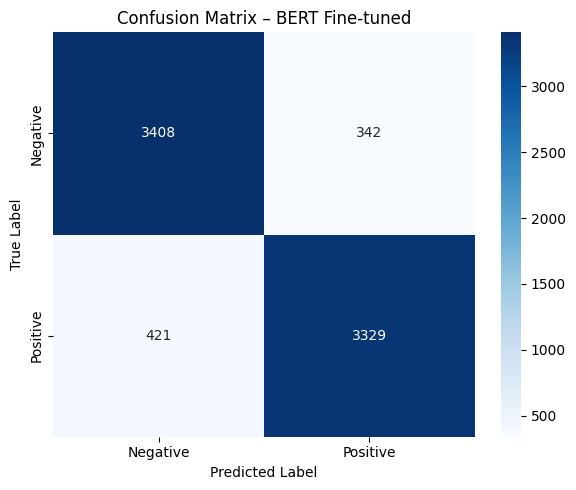

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(bert_true, bert_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title('Confusion Matrix – BERT Fine-tuned', fontsize=12)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../outputs/09_bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.8 Keyword Extraction (TF-IDF based NLP)

In [14]:
def extract_keywords(reviews_list, top_n=10, ngram_range=(1, 2)):
    """
    Extract top keywords from a list of reviews using TF-IDF.
    Used to highlight recurring themes in positive vs negative reviews.
    """
    tfidf  = TfidfVectorizer(max_features=5000, ngram_range=ngram_range,
                             stop_words='english', min_df=2)
    matrix = tfidf.fit_transform(reviews_list)
    scores = np.array(matrix.mean(axis=0)).flatten()
    vocab  = np.array(tfidf.get_feature_names_out())
    top_idx = scores.argsort()[-top_n:][::-1]
    return [(vocab[i], round(scores[i], 4)) for i in top_idx]

pos_reviews = test_df[test_df['label'] == 1]['cleaned_review'].tolist()
neg_reviews = test_df[test_df['label'] == 0]['cleaned_review'].tolist()

pos_kw = extract_keywords(pos_reviews, top_n=10)
neg_kw = extract_keywords(neg_reviews, top_n=10)

print('Top keywords in POSITIVE reviews:')
for kw, score in pos_kw:
    print(f'  {kw}: {score}')
print('\nTop keywords in NEGATIVE reviews:')
for kw, score in neg_kw:
    print(f'  {kw}: {score}')

Top keywords in POSITIVE reviews:
  movie: 0.0601
  film: 0.0568
  like: 0.0266
  good: 0.0246
  great: 0.0236
  story: 0.0232
  time: 0.0231
  character: 0.0219
  really: 0.0199
  make: 0.0186

Top keywords in NEGATIVE reviews:
  movie: 0.0678
  film: 0.0547
  like: 0.0299
  bad: 0.0254
  good: 0.0242
  time: 0.0232
  character: 0.0228
  really: 0.0213
  make: 0.0211
  story: 0.0198


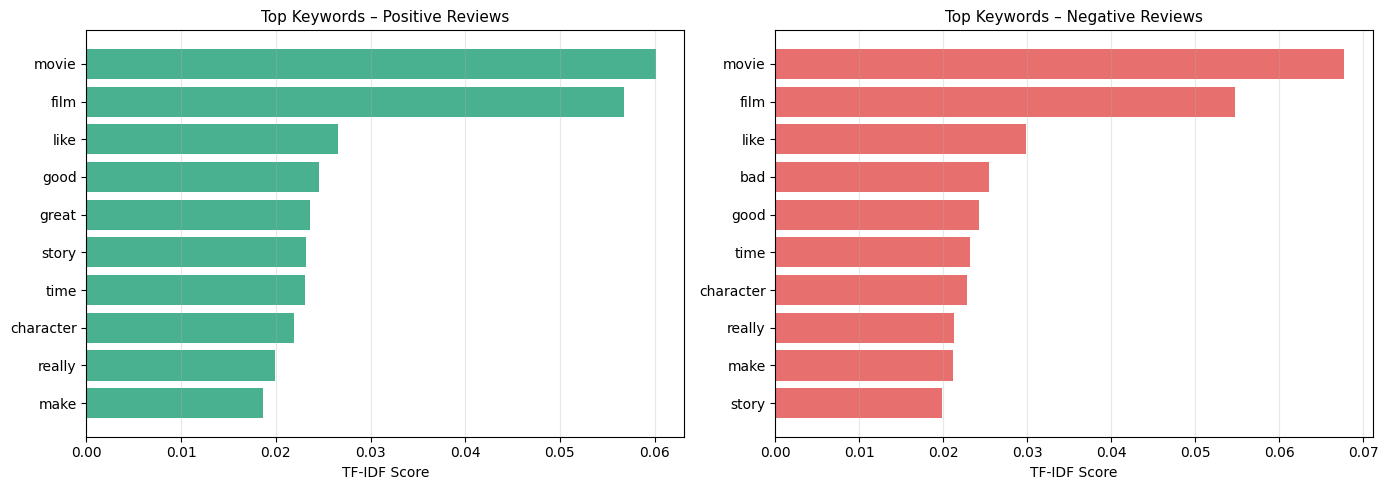

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, kw_list, title, color in [
    (axes[0], pos_kw, 'Top Keywords – Positive Reviews', '#1D9E75'),
    (axes[1], neg_kw, 'Top Keywords – Negative Reviews', '#E24B4A')
]:
    words  = [k[0] for k in kw_list]
    scores = [k[1] for k in kw_list]
    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('TF-IDF Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/08_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.9 Final Results Summary

In [16]:
# Pull best baseline for comparison
best_baseline_name = results_df.drop('BERT (Fine-tuned)').sort_values('Accuracy', ascending=False).index[0]
best_baseline_acc  = results_df.loc[best_baseline_name, 'Accuracy']
improvement        = (bert_acc - best_baseline_acc) * 100

# Load ROUGE scores saved by Notebook 3
try:
    rouge_df = pd.read_csv('../outputs/rouge_scores_by_prompt.csv', index_col=0)
    best_rouge1 = rouge_df['ROUGE-1'].max()
    best_rouge2 = rouge_df['ROUGE-2'].max()
    best_rougeL = rouge_df['ROUGE-L'].max()
    best_style  = rouge_df['ROUGE-1'].idxmax()
    rouge_loaded = True
except FileNotFoundError:
    rouge_loaded = False

print('=' * 60)
print('  MOVIE REVIEW SUMMARIZER – FINAL RESULTS SUMMARY')
print('=' * 60)

print('\n📦 Dataset')
print(f'   IMDb 50K Reviews | Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

print('\n🤖 Sentiment Classification (BERT Fine-tuned)')
print(f'   Accuracy : {bert_acc:.2%}')
print(f'   F1 Score : {bert_f1:.2%}')
print(f'   vs Best Baseline ({best_baseline_name}): {best_baseline_acc:.2%}  → +{improvement:.1f}% improvement')

print('\n📝 Summarization (Prompt Engineering)')
if rouge_loaded:
    print(f'   Best strategy : {best_style.upper()}')
    print(f'   ROUGE-1  : {best_rouge1:.4f}')
    print(f'   ROUGE-2  : {best_rouge2:.4f}')
    print(f'   ROUGE-L  : {best_rougeL:.4f}')
else:
    print('   Run Notebook 3 first to generate ROUGE scores.')

print('\n🔑 Keyword Extraction (TF-IDF NLP)')
print(f'   Top themes identified: {", ".join([k for k,_ in pos_kw[:3]])} (positive)')
print(f'                          {", ".join([k for k,_ in neg_kw[:3]])} (negative)')

print('\n⚙️  AI Techniques Used')
print('   ✅ NLP: text preprocessing, tokenization, TF-IDF')
print('   ✅ Word Embeddings: Word2Vec (100-dim, window=5)')
print('   ✅ Transformer: DistilBERT fine-tuned for classification')
print('   ✅ Transfer Learning: pre-trained → domain fine-tuning')
print('   ✅ Prompt Engineering: 4 styles + chain-of-thought')
print('   ✅ In-context Learning: batch verdict aggregation')

print('\n📊 Evaluation Metrics')
print('   Accuracy, F1, Confusion Matrix, ROUGE-1/2/L, Baseline Comparison')
print('=' * 60)

  MOVIE REVIEW SUMMARIZER – FINAL RESULTS SUMMARY

📦 Dataset
   IMDb 50K Reviews | Train: 35,000 | Val: 7,500 | Test: 7,500

🤖 Sentiment Classification (BERT Fine-tuned)
   Accuracy : 89.83%
   F1 Score : 89.72%
   vs Best Baseline (Linear SVM): 90.56%  → +-0.7% improvement

📝 Summarization (Prompt Engineering)
   Best strategy : COT
   ROUGE-1  : 0.6131
   ROUGE-2  : 0.5575
   ROUGE-L  : 0.6037

🔑 Keyword Extraction (TF-IDF NLP)
   Top themes identified: movie, film, like (positive)
                          movie, film, like (negative)

⚙️  AI Techniques Used
   ✅ NLP: text preprocessing, tokenization, TF-IDF
   ✅ Word Embeddings: Word2Vec (100-dim, window=5)
   ✅ Transformer: DistilBERT fine-tuned for classification
   ✅ Transfer Learning: pre-trained → domain fine-tuning
   ✅ Prompt Engineering: 4 styles + chain-of-thought
   ✅ In-context Learning: batch verdict aggregation

📊 Evaluation Metrics
   Accuracy, F1, Confusion Matrix, ROUGE-1/2/L, Baseline Comparison
